<a href="https://colab.research.google.com/github/Swag-Pseudopy/Escaping-Preference-Collapse/blob/main/nlhf_advanced_sims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random # Add this import

# ==========================================
# 0. Global Seed for NeurIPS Reproducibility
# ==========================================
def set_global_seed(seed=42):
    """Locks all random number generators to ensure deterministic plots."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # If you ever move to GPU for larger simulations
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Call it immediately
set_global_seed(1010)

In [92]:
# ==========================================
# 1. Stochasticity Gap (Mini-Batch Noise)
# ==========================================
def simulate_stochastic_drift(iterations=1000):
    A = np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])
    eta = 0.05
    tau = 0.025 # This was the perfectly stable tau in the deterministic case
    p_start = np.array([0.6, 0.3, 0.1])
    C_min = 3 * np.log(3)

    noise_levels = [0.0, 0.5, 1.0] # Standard deviations of batch noise
    trajectories = {std: [] for std in noise_levels}

    for std in noise_levels:
        p = p_start.copy()
        for _ in range(iterations):
            trajectories[std].append(-np.sum(np.log(p)) - C_min)
            # Add stochastic gradient noise to the advantage vector
            noisy_advantage = A @ p + np.random.normal(0, std, size=3)
            # Ensure zero-sum property is roughly maintained for the noise
            noisy_advantage -= np.mean(noisy_advantage)

            p_ref = np.array([1/3, 1/3, 1/3])
            log_unnorm = (1 - eta*tau)*np.log(p) + (eta*tau)*np.log(p_ref) + eta*noisy_advantage
            log_unnorm -= np.max(log_unnorm)
            p_next = np.exp(log_unnorm)
            p = p_next / np.sum(p_next)

    plt.figure(figsize=(8, 5))
    for std in noise_levels:
        plt.plot(trajectories[std], label=f"Batch Noise Std = {std}", alpha=0.8)
    plt.title("Impact of Stochastic Mini-Batch Noise on Cycle Stability", fontsize=12)
    plt.xlabel("Iterations")
    plt.ylabel(r"Excess Energy $\tilde{C}_t$")
    plt.yscale("symlog", linthresh=0.1)
    plt.axhline(0, color='k', linestyle='--', label="Nash Equilibrium")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("stochastic_drift.png", dpi=300, bbox_inches='tight')

In [93]:
# ==========================================
# 2. N-Dimensional Generalization
# ==========================================
def simulate_n_dimensional_cycles(n=50, iterations=1500):
    # Generate random skew-symmetric matrix (Random Tournament)
    M = np.random.randn(n, n)
    A = M - M.T

    eta, tau = 0.01, 0.002 # Stable-ish ratio for this dimension
    p = np.random.dirichlet(np.ones(n)) # Random initial policy
    p_ref = np.ones(n) / n
    C_min = n * np.log(n)

    energy_trajectory = []
    for _ in range(iterations):
        energy_trajectory.append(-np.sum(np.log(p)) - C_min)
        log_unnorm = (1 - eta*tau)*np.log(p) + (eta*tau)*np.log(p_ref) + eta*(A @ p)
        log_unnorm -= np.max(log_unnorm)
        p_next = np.exp(log_unnorm)
        p = p_next / np.sum(p_next)

    plt.figure(figsize=(8, 5))
    plt.plot(energy_trajectory, color='purple', label=f"{n}-Dimensional Orbit")
    plt.title(f"Algorithmic Drift in High-Dimensional Simplex ($N={n}$)", fontsize=12)
    plt.xlabel("Iterations")
    plt.ylabel(r"Excess Energy $\tilde{C}_t$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("n_dim_drift.png", dpi=300, bbox_inches='tight')

In [94]:
# ==========================================
# 3. PyTorch Parameterized Policy (Neural Net)
# ==========================================
class SimplePolicyNet(nn.Module):
    def __init__(self, context_dim=10, num_actions=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(context_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_actions)
        )
    def forward(self, x):
        return F.log_softmax(self.net(x), dim=-1)

# def simulate_neural_network_drift(epochs=500):
#     A_tensor = torch.tensor([[0., 1., -1.], [-1., 0., 1.], [1., -1., 0.]])
#     x_context = torch.randn(1, 10) # Fixed context (prompt)

#     taus = {"Expansive": 0.01, "Stable": 0.1, "Collapsing": 0.5}
#     eta = 0.1
#     C_min = 3 * np.log(3)

#     trajectories = {k: [] for k in taus.keys()}

#     for label, tau in taus.items():
#         model = SimplePolicyNet()
#         ref_model = SimplePolicyNet()
#         ref_model.load_state_dict(model.state_dict()) # Same initialization
#         optimizer = optim.SGD(model.parameters(), lr=0.05)

#         for _ in range(epochs):
#             optimizer.zero_grad()
#             with torch.no_grad():
#                 log_p_ref = ref_model(x_context)[0]
#                 p_ref = torch.exp(log_p_ref)

#             log_p_current = model(x_context)[0]
#             p_current = torch.exp(log_p_current)

#             # Record Energy
#             trajectories[label].append((-torch.sum(torch.log(p_current)) - C_min).item())

#             # Construct target Nash-MD distribution (Bellman-like target)
#             with torch.no_grad():
#                 advantage = torch.matmul(A_tensor, p_current)
#                 log_target = (1 - eta*tau)*log_p_current + (eta*tau)*log_p_ref + eta*advantage
#                 p_target = F.softmax(log_target, dim=-1)

#             # Deep Learning Objective: Match the target distribution via KL Divergence
#             loss = F.kl_div(model(x_context)[0], p_target, reduction='batchmean', log_target=False)
#             loss.backward()
#             optimizer.step()

#     plt.figure(figsize=(8, 5))
#     colors = ['red', 'green', 'blue']
#     for (label, traj), c in zip(trajectories.items(), colors):
#         plt.plot(traj, label=f"NN {label} ($\\tau={taus[label]}$)", color=c)
#     plt.title("Phase Transition in Parameterized Neural Networks", fontsize=12)
#     plt.xlabel("Gradient Steps")
#     plt.ylabel(r"NN Output Excess Energy $\tilde{C}_t$")
#     plt.yscale("symlog", linthresh=0.01)
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig("nn_drift.png", dpi=300, bbox_inches='tight')

def simulate_neural_network_drift(epochs=500):
    A_tensor = torch.tensor([[0., 1., -1.], [-1., 0., 1.], [1., -1., 0.]])
    x_context = torch.randn(1, 10)

    # 1. Lock seed for perfect initialization alignment
    torch.manual_seed(42)
    master_model = SimplePolicyNet()

    taus = {"Expansive": 1e-8, "Stable": 0.02, "Collapsing": 0.5}
    eta = 0.1
    C_min = 3 * np.log(3)

    trajectories = {k: [] for k in taus.keys()}

    for label, tau in taus.items():
        model = SimplePolicyNet()
        model.load_state_dict(master_model.state_dict())

        # 2. INCREASED LEARNING RATE (Centrifugal Force multiplier)
        optimizer = optim.SGD(model.parameters(), lr=0.5)

        # 3. True Mathematical Nash Equilibrium Target
        p_ref = torch.tensor([1/3, 1/3, 1/3])
        log_p_ref = torch.log(p_ref)

        for _ in range(epochs):
            optimizer.zero_grad()

            log_p_current = model(x_context)[0]
            p_current = torch.exp(log_p_current)

            trajectories[label].append((-torch.sum(torch.log(p_current)) - C_min).item())

            with torch.no_grad():
                advantage = torch.matmul(A_tensor, p_current)
                log_target = (1 - eta*tau)*log_p_current + (eta*tau)*log_p_ref + eta*advantage
                p_target = F.softmax(log_target, dim=-1)

            loss = F.kl_div(model(x_context)[0], p_target, reduction='batchmean', log_target=False)
            loss.backward()
            optimizer.step()

    plt.figure(figsize=(8, 5))
    colors = ['red', 'green', 'blue']
    for (label, traj), c in zip(trajectories.items(), colors):
        plt.plot(traj, label=f"NN {label} ($\\tau={taus[label]}$)", color=c)
    plt.title("Phase Transition in Parameterized Neural Networks", fontsize=12)
    plt.xlabel("Gradient Steps")
    plt.ylabel(r"NN Output Excess Energy $\tilde{C}_t$")
    plt.yscale("symlog", linthresh=0.01)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("nn_drift_final.png", dpi=300, bbox_inches='tight')

PDF plots generated successfully.


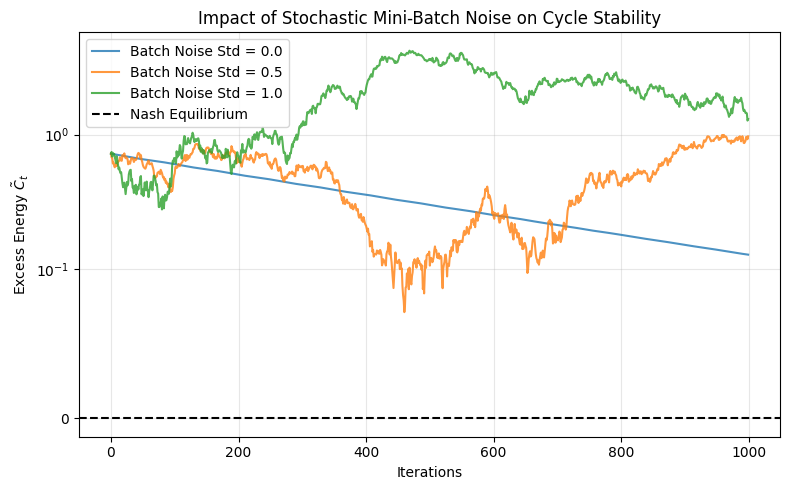

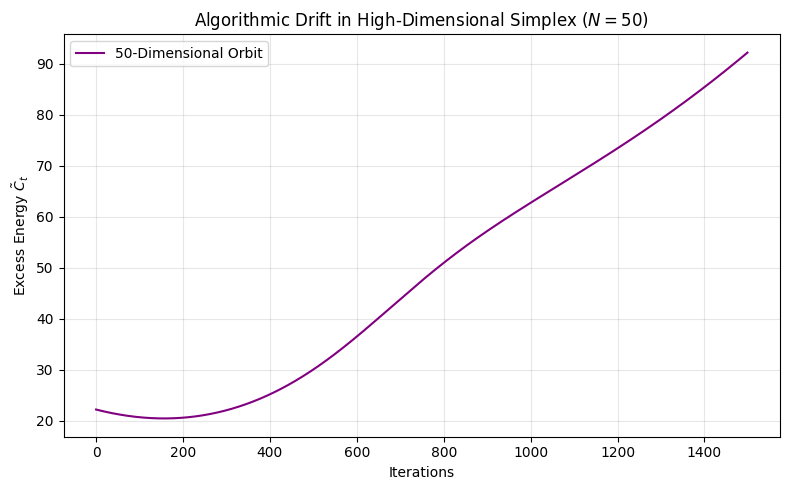

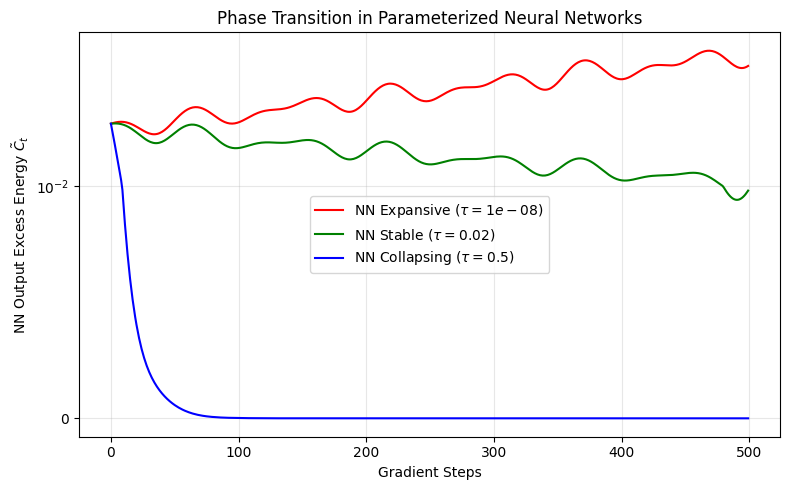

In [95]:
if __name__ == "__main__":
    simulate_stochastic_drift()
    simulate_n_dimensional_cycles()
    simulate_neural_network_drift()
    print("PDF plots generated successfully.")